In [ ]:
import warnings
import pandas as pd


import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


import scipy.stats as stats
from scipy.stats import pearsonr, mannwhitneyu, kruskal, chi2_contingency

from tabulate import tabulate
import os

warnings.filterwarnings('ignore')


colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#bcbd22"]
ordered_colors = [colors[0], colors[1], colors[2], colors[3], colors[4]]

sns.set_palette(colors)


df = pd.read_csv('../df/raw/Customer-Churn-Records.csv')
print(df)

      RowNumber  CustomerId    Surname  CreditScore Geography  Gender  Age  \
0             1    15634602   Hargrave          619    France  Female   42   
1             2    15647311       Hill          608     Spain  Female   41   
2             3    15619304       Onio          502    France  Female   42   
3             4    15701354       Boni          699    France  Female   39   
4             5    15737888   Mitchell          850     Spain  Female   43   
...         ...         ...        ...          ...       ...     ...  ...   
9995       9996    15606229   Obijiaku          771    France    Male   39   
9996       9997    15569892  Johnstone          516    France    Male   35   
9997       9998    15584532        Liu          709    France  Female   36   
9998       9999    15682355  Sabbatini          772   Germany    Male   42   
9999      10000    15628319     Walker          792    France  Female   28   

      Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMemb

In [9]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
6622,6623,15679307,Kazantseva,559,France,Female,43,1,0.00,1,0,1,86634.30,0,0,5,PLATINUM,830
8169,8170,15689517,Hales,635,France,Male,27,3,127009.83,1,1,0,161909.95,0,0,1,GOLD,686
8930,8931,15665759,Russell,724,France,Female,69,5,117866.92,1,1,1,62280.91,0,0,3,PLATINUM,876
2394,2395,15716284,Ward,543,France,Male,43,9,0.00,2,1,1,78858.07,0,0,5,SILVER,380
1648,1649,15655574,Okeke,698,Germany,Female,40,8,150777.10,1,1,0,114732.62,0,0,3,GOLD,981


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

In [13]:
df.isna().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [17]:
irrelevant_columns = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=irrelevant_columns, errors='ignore')

In [19]:
numerical_cols = []
categorical_cols = []

for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        unique_values = df[col].nunique()
        if unique_values <=5:
            categorical_cols.append(col)
        else:
            numerical_cols.append(col)
    else:
        categorical_cols.append(col)

In [20]:
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Point Earned']
Categorical Columns: ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type']


In [21]:
df[numerical_cols].describe()

,CreditScore,Age,Tenure,Balance,EstimatedSalary,Point Earned
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,100090.239881,606.515100
std,96.653299,10.487806,2.892174,62397.405202,57510.492818,225.924839
min,350.000000,18.000000,0.000000,0.000000,11.580000,119.000000
25%,584.000000,32.000000,3.000000,0.000000,51002.110000,410.000000
50%,652.000000,37.000000,5.000000,97198.540000,100193.915000,605.000000
75%,718.000000,44.000000,7.000000,127644.240000,149388.247500,801.000000
max,850.000000,92.000000,10.000000,250898.090000,199992.480000,1000.000000


In [24]:
def plot_distributions(df, ordered_colors):

    numeric_columns = df.columns

    extended_colors = (ordered_colors * (len(numeric_columns) // len(ordered_colors) + 1))[:len(numeric_columns)]

    plt.style.use('seaborn-v0_8-whitegrid')
    sns.set_context("notebook", font_scale=1.2)

    for i, col in enumerate(numeric_columns):

        fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={'width_ratios': [2, 1, 2]})
        fig.suptitle(f'Univariate Analysis of {col}', fontsize=16, weight='bold', y=1.05)

        sns.histplot(df[col], kde=True, color=extended_colors[i], ax=axes[0], bins=30)
        axes[0].set_title(f'{col} Histogram', fontsize=14)
        axes[0].set_xlabel(col, fontsize=12)
        axes[0].set_ylabel('Frequency', fontsize=12)

        mean_val = df[col].mean()
        median_val = df[col].median()
        axes[0].axvline(mean_val, color='green', linestyle='--', label=f'Mean: {mean_val:.2f}')
        axes[0].axvline(median_val, color='purple', linestyle='-', label=f'Median: {median_val:.2f}')
        axes[0].legend(fontsize=10)

        sns.boxplot(y=df[col], ax=axes[1], color=extended_colors[i], flierprops=dict(marker='o', markerfacecolor='red', markersize=8))
        axes[1].set_title(f'{col} Box Plot', fontsize=14)
        axes[1].set_ylabel(col, fontsize=12)


        stats.probplot(df[col], dist="norm", plot=axes[2] , rvalue=True)
        axes[2].set_title(f'{col} Q-Q Plot', fontsize=14)
        axes[2].set_xlabel('Theoretical Quantiles', fontsize=12)
        axes[2].set_ylabel('Sample Quantiles', fontsize=12)

        skewness = stats.skew(df[col])
        kurtosis = stats.kurtosis(df[col])

        stats_text = f'{col} Skewness: {skewness:.2f}\n{col} Kurtosis: {kurtosis:.2f}'
        fig.text(0.01, 0.95, stats_text, fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

        plt.tight_layout()
        plt.show()


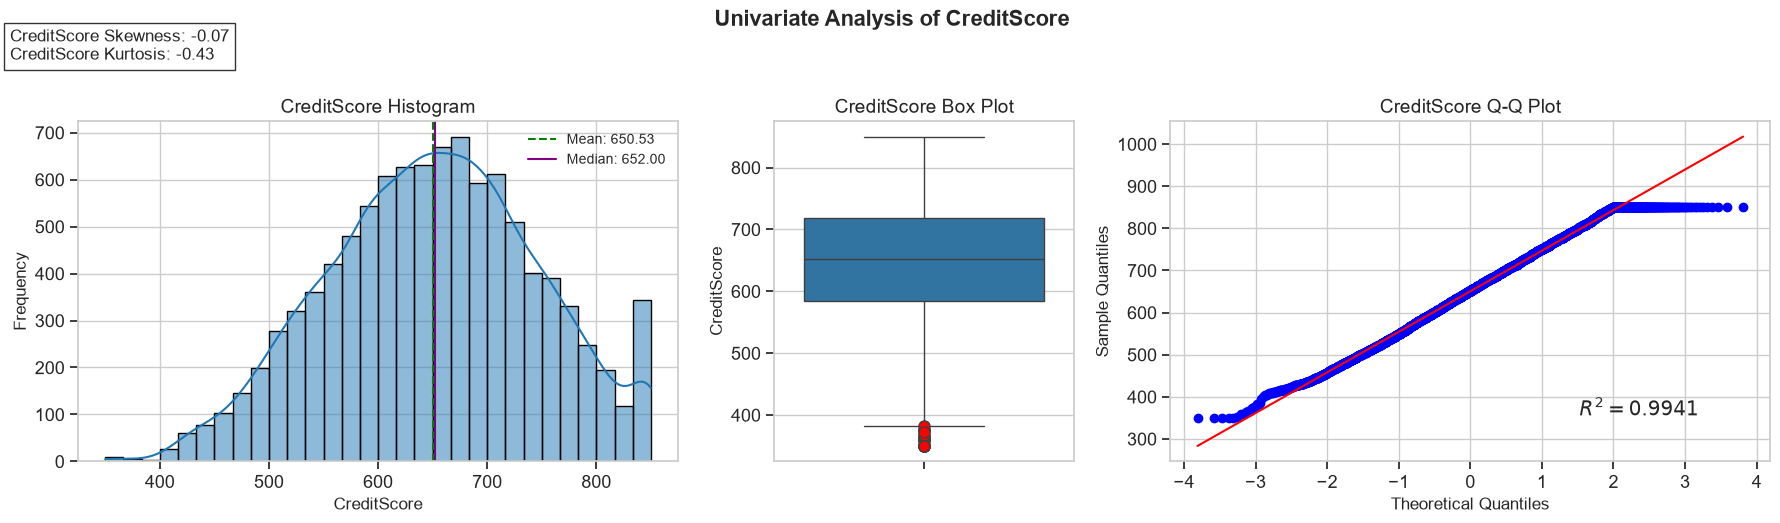

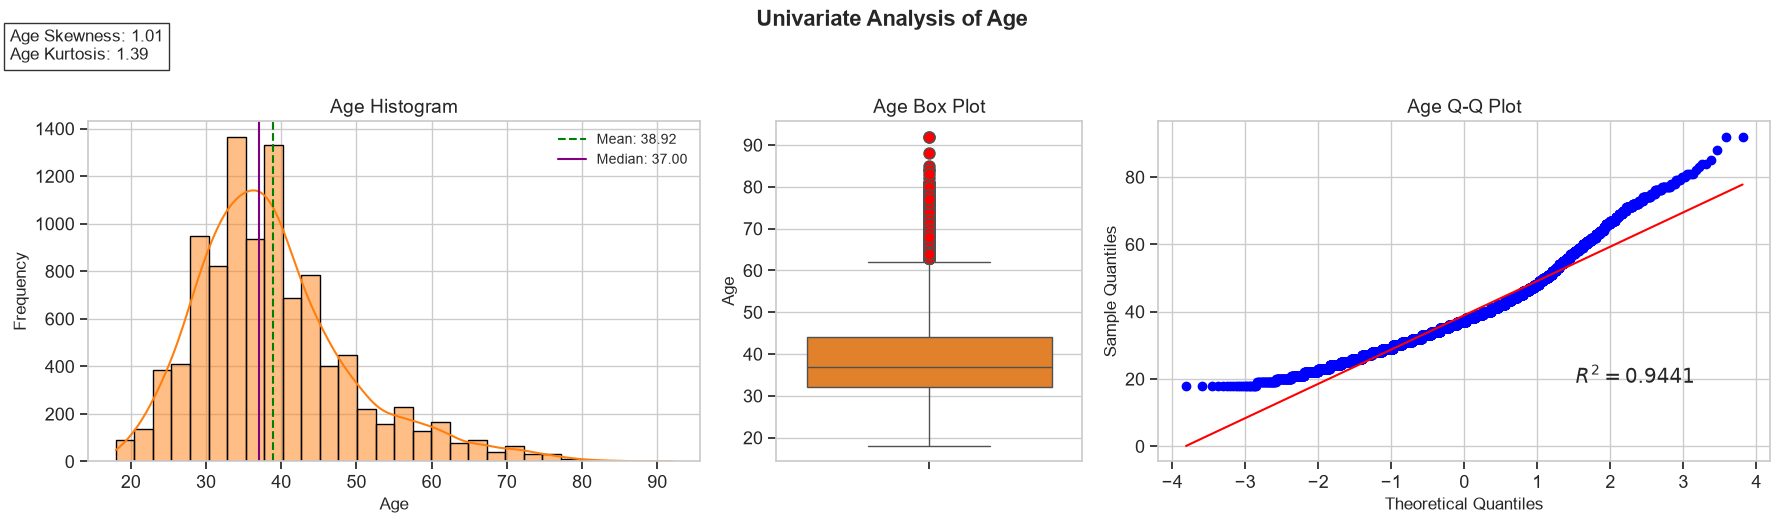

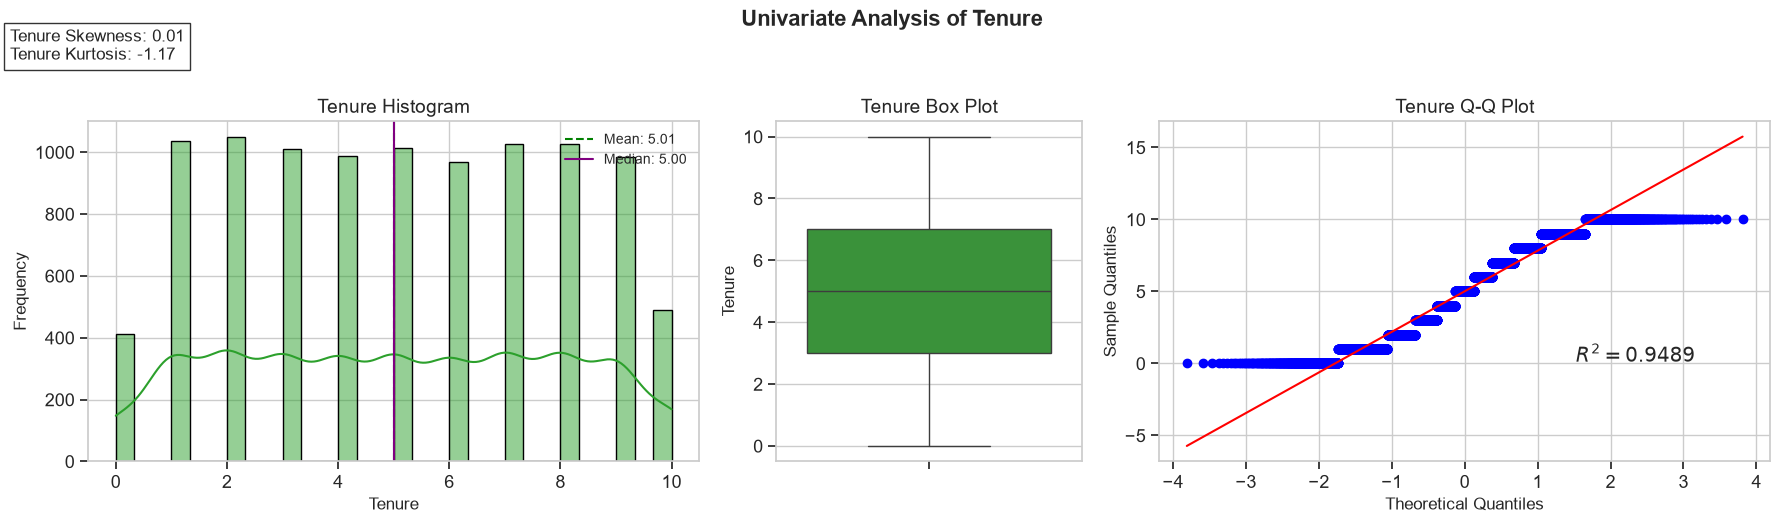

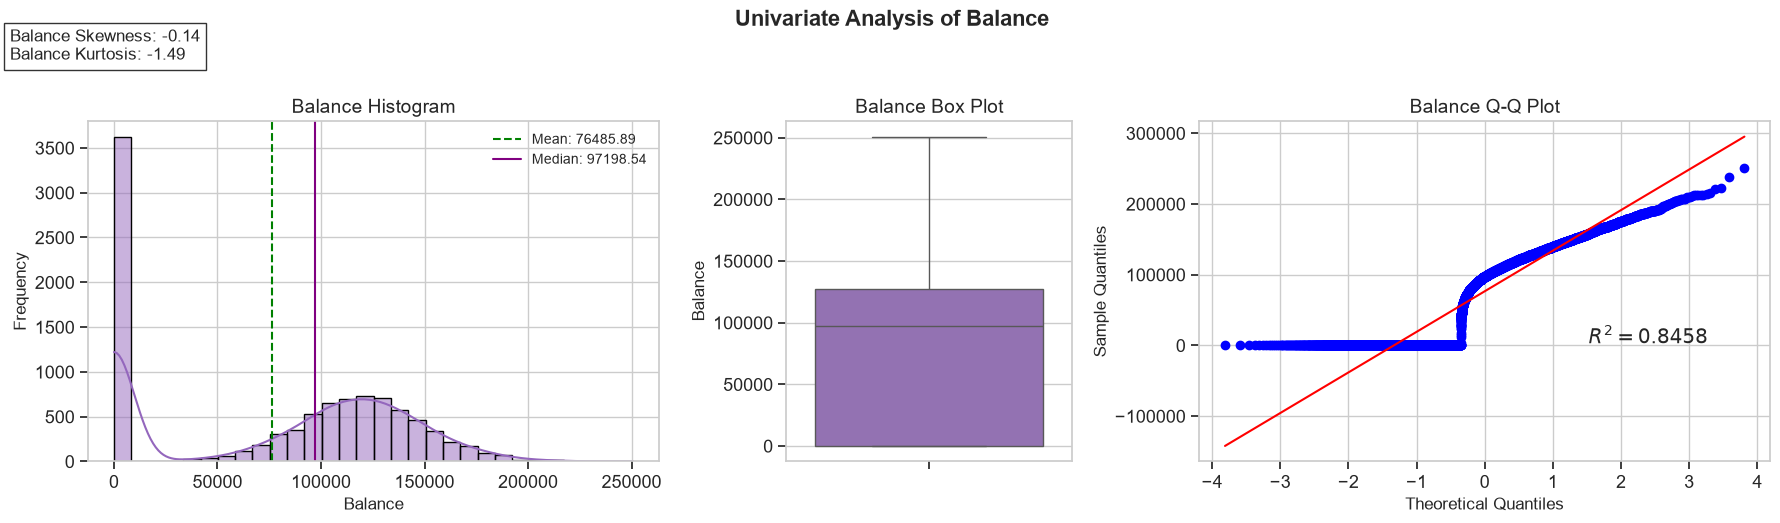

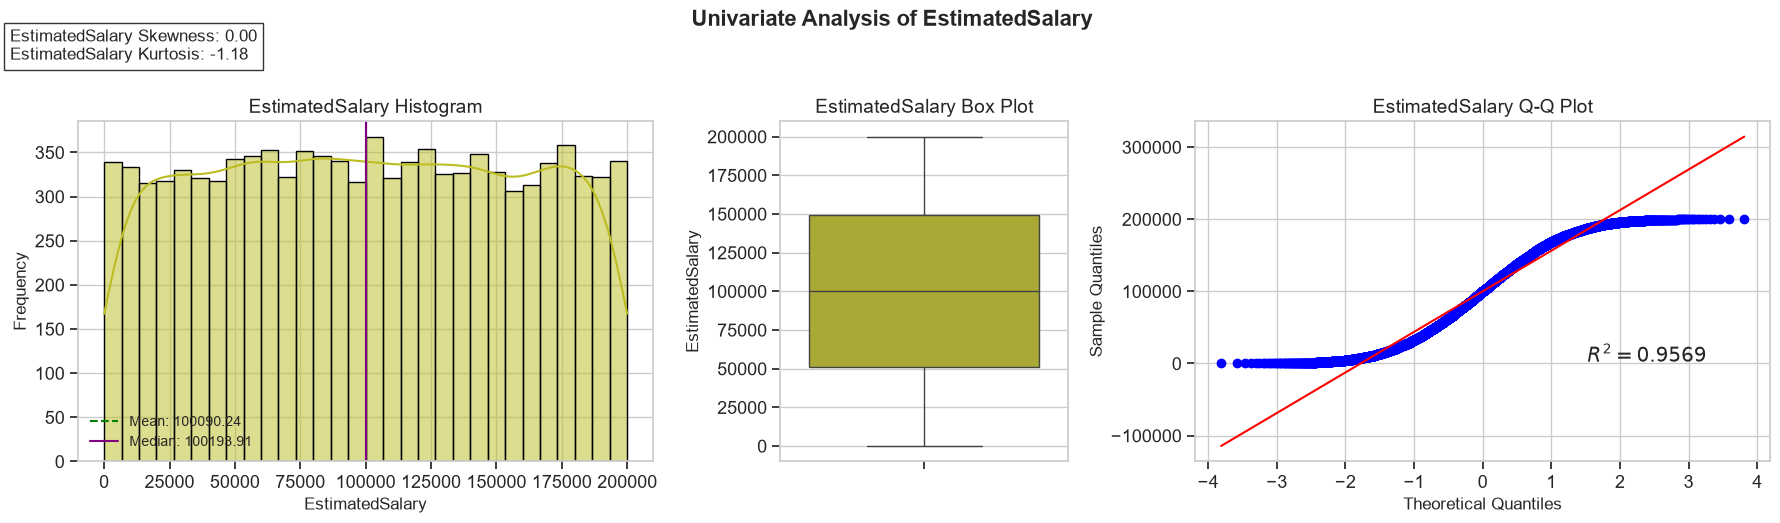

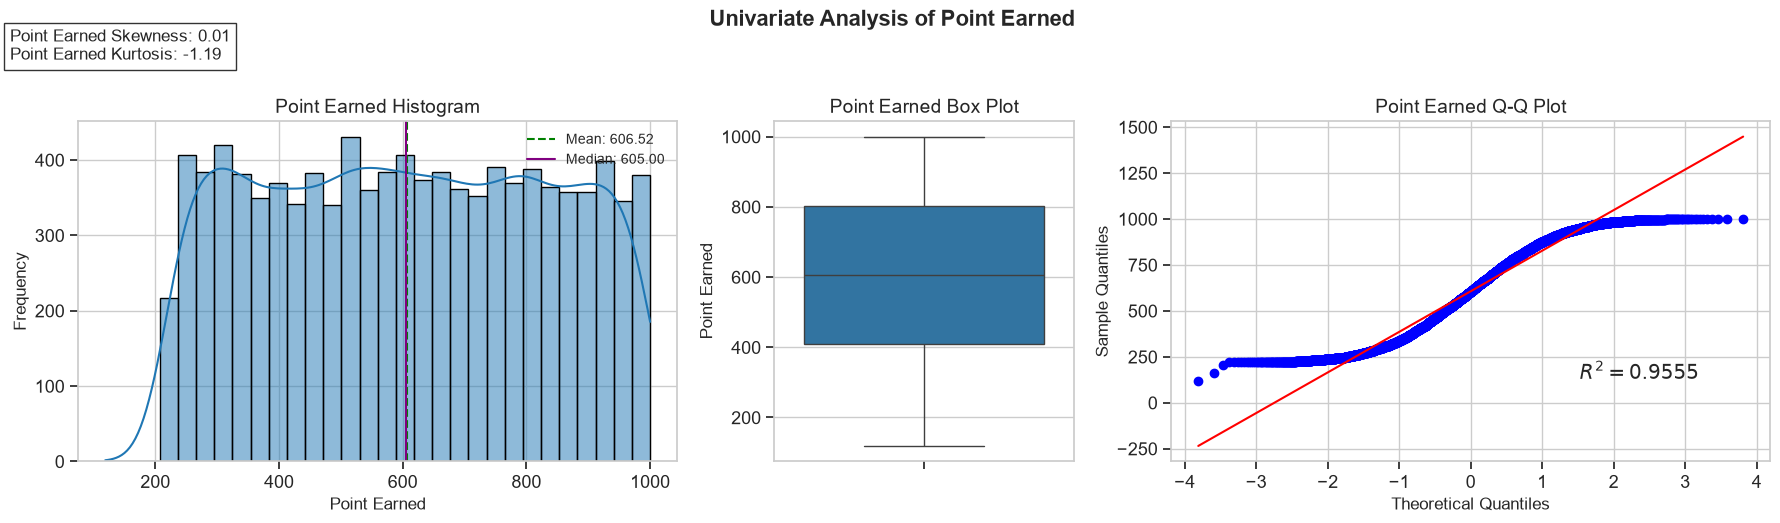

In [25]:
plot_distributions(df[numerical_cols], ordered_colors)

In [33]:
def plot_categorical_features(df):

    categorical_cols = df.columns.to_list()

    plt.style.use('seaborn-v0_8')
    custom_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f', '#9b59b6'] 
    sns.set_palette(custom_palette)

    for col in categorical_cols:
        labels = df[col].value_counts().keys()
        counts = df[col].value_counts().values


        pie_labels = [f'{label}\n({(count / len(df) * 100):.1f}%)' for label, count in zip(labels, counts)]

        plt.figure(figsize=(6, 4))
        plt.pie(counts, labels=pie_labels, shadow=True,
                explode=[0.1 if i == 0 else 0 for i in range(len(labels))],
                startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})

        plt.title(f'Distribution of {col}', fontsize=14, pad=20, weight='bold')
        plt.axis('equal')
        plt.tight_layout()
        plt.show()

 
        value_counts = df[col].value_counts()
        relative_freq = (df[col].value_counts(normalize=True) * 100).round(1)
        table_df = pd.DataFrame({
            'Value': value_counts.index,
            'Count': value_counts.values,
            'Relative Frequency (%)': relative_freq.values
        })
        print(tabulate(table_df, headers='keys', tablefmt='psql', showindex=False))
        print("\n")

 


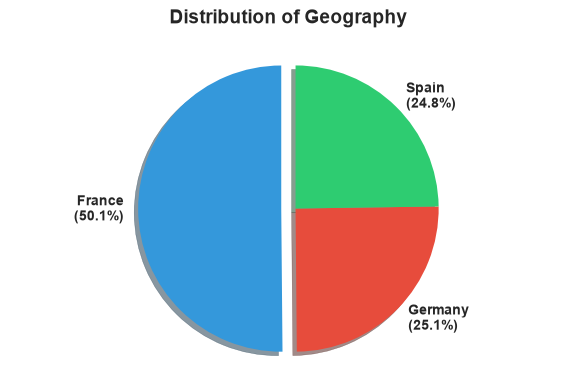

+---------+---------+--------------------------+
| Value   |   Count |   Relative Frequency (%) |
|---------+---------+--------------------------|
| France  |    5014 |                     50.1 |
| Germany |    2509 |                     25.1 |
| Spain   |    2477 |                     24.8 |
+---------+---------+--------------------------+




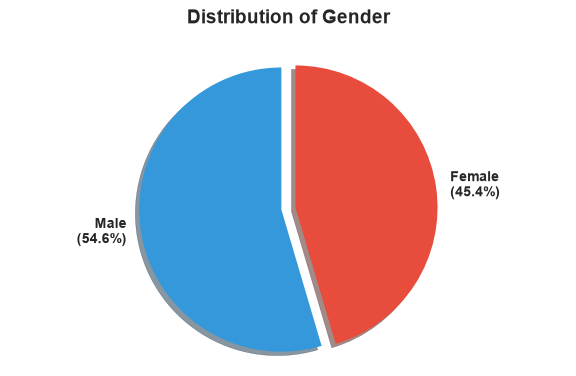

+---------+---------+--------------------------+
| Value   |   Count |   Relative Frequency (%) |
|---------+---------+--------------------------|
| Male    |    5457 |                     54.6 |
| Female  |    4543 |                     45.4 |
+---------+---------+--------------------------+




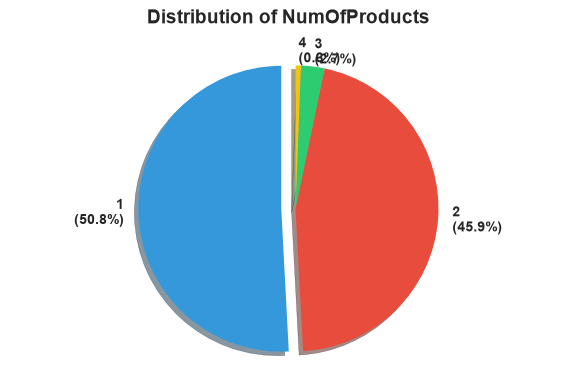

+---------+---------+--------------------------+
|   Value |   Count |   Relative Frequency (%) |
|---------+---------+--------------------------|
|       1 |    5084 |                     50.8 |
|       2 |    4590 |                     45.9 |
|       3 |     266 |                      2.7 |
|       4 |      60 |                      0.6 |
+---------+---------+--------------------------+




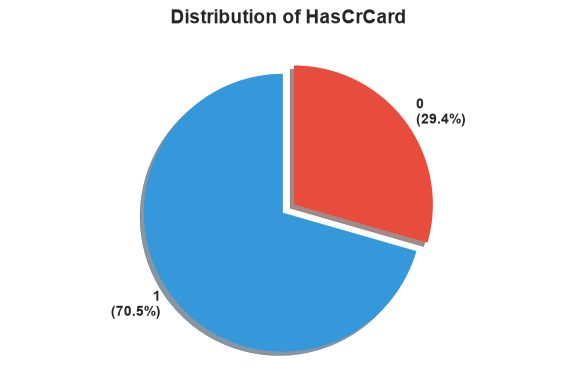

+---------+---------+--------------------------+
|   Value |   Count |   Relative Frequency (%) |
|---------+---------+--------------------------|
|       1 |    7055 |                     70.6 |
|       0 |    2945 |                     29.4 |
+---------+---------+--------------------------+




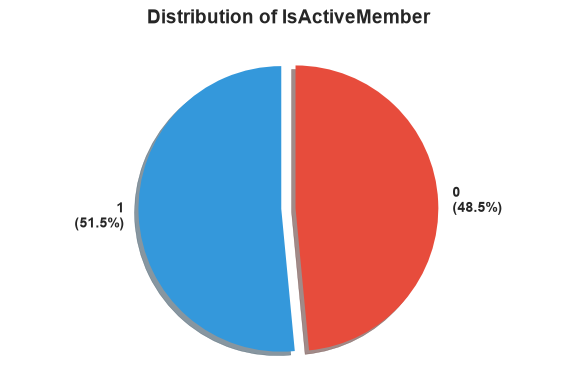

+---------+---------+--------------------------+
|   Value |   Count |   Relative Frequency (%) |
|---------+---------+--------------------------|
|       1 |    5151 |                     51.5 |
|       0 |    4849 |                     48.5 |
+---------+---------+--------------------------+




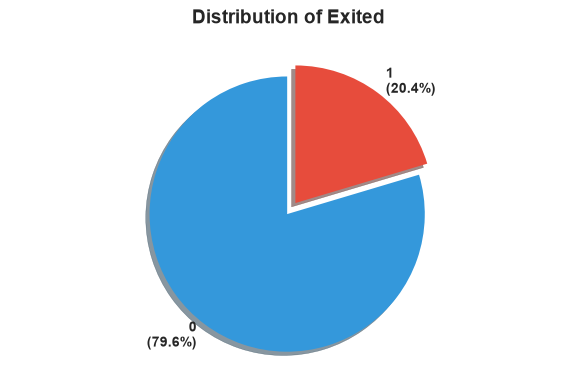

+---------+---------+--------------------------+
|   Value |   Count |   Relative Frequency (%) |
|---------+---------+--------------------------|
|       0 |    7962 |                     79.6 |
|       1 |    2038 |                     20.4 |
+---------+---------+--------------------------+




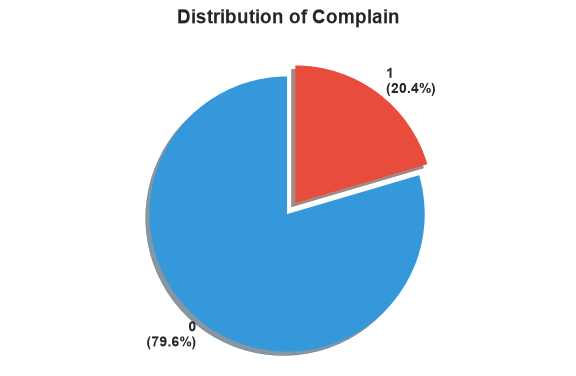

+---------+---------+--------------------------+
|   Value |   Count |   Relative Frequency (%) |
|---------+---------+--------------------------|
|       0 |    7956 |                     79.6 |
|       1 |    2044 |                     20.4 |
+---------+---------+--------------------------+




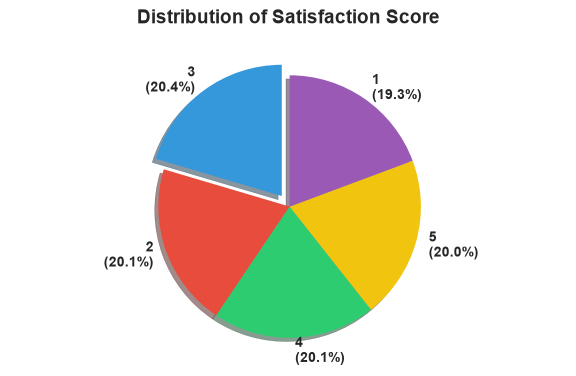

+---------+---------+--------------------------+
|   Value |   Count |   Relative Frequency (%) |
|---------+---------+--------------------------|
|       3 |    2042 |                     20.4 |
|       2 |    2014 |                     20.1 |
|       4 |    2008 |                     20.1 |
|       5 |    2004 |                     20   |
|       1 |    1932 |                     19.3 |
+---------+---------+--------------------------+




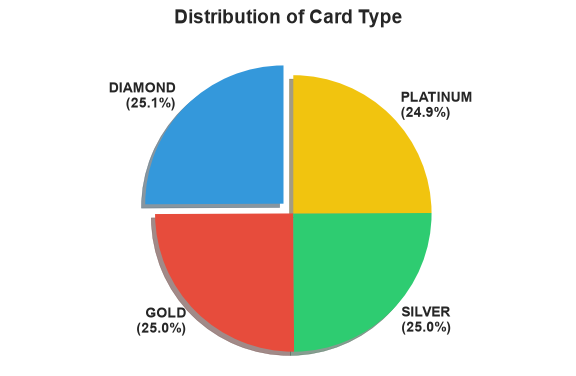

+----------+---------+--------------------------+
| Value    |   Count |   Relative Frequency (%) |
|----------+---------+--------------------------|
| DIAMOND  |    2507 |                     25.1 |
| GOLD     |    2502 |                     25   |
| SILVER   |    2496 |                     25   |
| PLATINUM |    2495 |                     25   |
+----------+---------+--------------------------+




In [34]:
plot_categorical_features(df[categorical_cols])

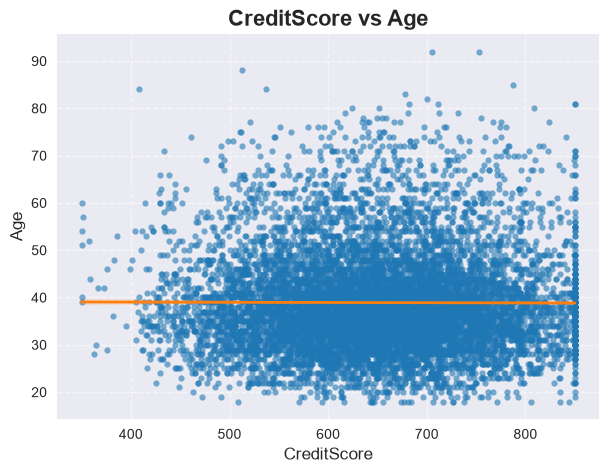

In [ ]:
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='CreditScore', y='Age',
            scatter_kws={'color': '#1f77b4', 'alpha': 0.6, 's': 20}, 
            line_kws={'color': '#ff7f0e', 'lw': 2})
plt.title('CreditScore vs Age', fontsize=16, fontweight='bold')
plt.xlabel('CreditScore', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.show()

In [40]:
correlation, p_value = pearsonr(df['CreditScore'], df['Age'])
print(f'Pearson Correlation: {correlation:.3f}, p-value: {p_value:.3f}')

Pearson Correlation: -0.004, p-value: 0.692


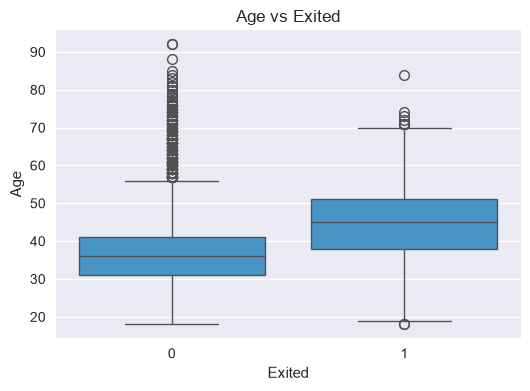

In [41]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Exited', y='Age')
plt.title('Age vs Exited')
plt.xlabel('Exited')
plt.ylabel('Age')
plt.show()


In [42]:
exited_0 = df[df['Exited'] == 0]['Age']
exited_1 = df[df['Exited'] == 1]['Age']
stat, p_value = mannwhitneyu(exited_0, exited_1)
print(f'Mann-Whitney U Statistic: {stat:.3f}, p-value: {p_value:.3f}')

Mann-Whitney U Statistic: 4347741.000, p-value: 0.000


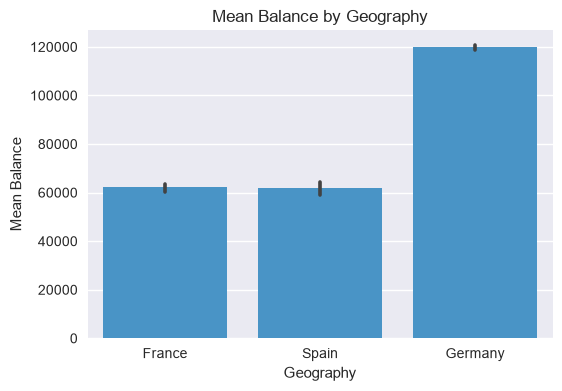

In [43]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Geography', y='Balance', estimator='mean')
plt.title('Mean Balance by Geography')
plt.xlabel('Geography')
plt.ylabel('Mean Balance')
plt.show()

In [47]:
groups = [df[df['Geography'] == g]['Balance'] for g in df['Geography'].unique()]
stat, p_value = kruskal(*groups)
print(f'Kruskal-Wallis Statistic: {stat:.3f}, p-value: {p_value:.3f}')

Kruskal-Wallis Statistic: 1381.934, p-value: 0.000


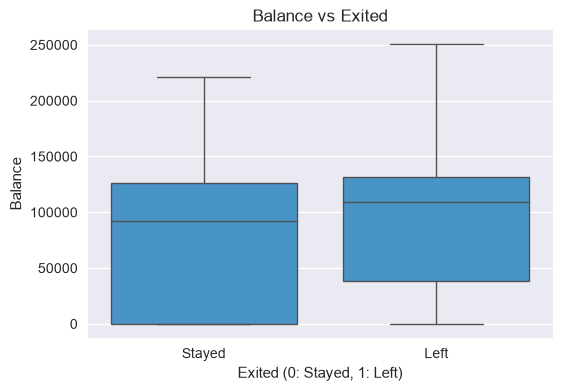

In [45]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Exited', y='Balance')
plt.title('Balance vs Exited')
plt.xlabel('Exited (0: Stayed, 1: Left)')
plt.ylabel('Balance')
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.show()

In [48]:
stat, p_value = mannwhitneyu(exited_0, exited_1)
print(f'Mann-Whitney U Statistic: {stat:.3f}, p-value: {p_value:.3f}')

Mann-Whitney U Statistic: 4347741.000, p-value: 0.000


In [49]:
df['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

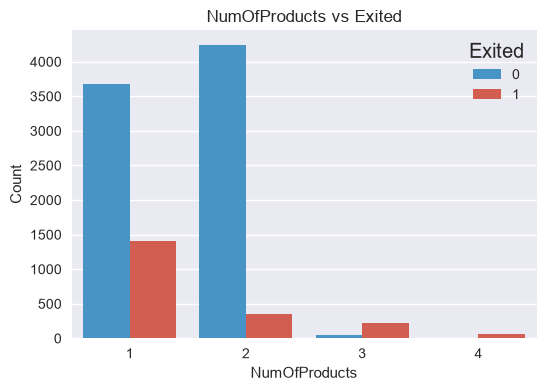

In [50]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='NumOfProducts', hue='Exited')
plt.title('NumOfProducts vs Exited')
plt.xlabel('NumOfProducts')
plt.ylabel('Count')
plt.show()

In [51]:
contingency_table = pd.crosstab(df['NumOfProducts'], df['Exited'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f'Chi-Square Statistic: {chi2:.3f}, p-value: {p_value:.3f}')

Chi-Square Statistic: 1501.505, p-value: 0.000


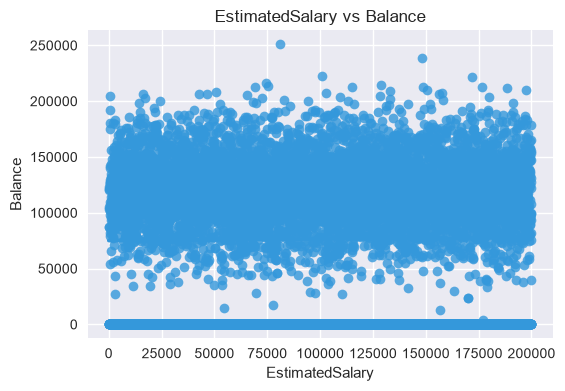

In [52]:
plt.figure(figsize=(6, 4))
sns.regplot(data=df, x='EstimatedSalary', y='Balance')
plt.title('EstimatedSalary vs Balance')
plt.xlabel('EstimatedSalary')
plt.ylabel('Balance')
plt.show()

In [53]:
correlation, p_value = pearsonr(df['EstimatedSalary'], df['Balance'])
print(f'Pearson Correlation: {correlation:.3f}, p-value: {p_value:.3f}')

Pearson Correlation: 0.013, p-value: 0.201


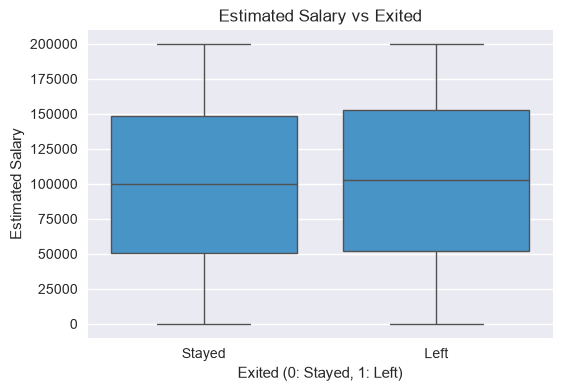

In [54]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Exited', y='EstimatedSalary')
plt.title('Estimated Salary vs Exited')
plt.xlabel('Exited (0: Stayed, 1: Left)')
plt.ylabel('Estimated Salary')
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.show()


In [55]:
exited_0 = df[df['Exited'] == 0]['EstimatedSalary']
exited_1 = df[df['Exited'] == 1]['EstimatedSalary']

stat, p_value = mannwhitneyu(exited_0, exited_1)
print(f'Mann-Whitney U Statistic: {stat:.3f}, p-value: {p_value:.3f}')

Mann-Whitney U Statistic: 7968250.000, p-value: 0.212


<Figure size 600x400 with 0 Axes>

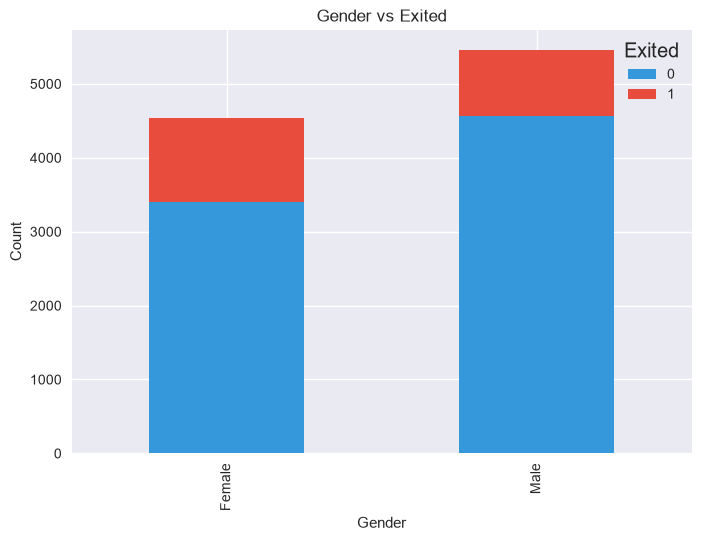

In [56]:
plt.figure(figsize=(6, 4))
pd.crosstab(df['Gender'], df['Exited']).plot(kind='bar', stacked=True)
plt.title('Gender vs Exited')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Exited')
plt.show()

In [57]:
contingency_table = pd.crosstab(df['Gender'], df['Exited'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f'Chi-Square Statistic: {chi2:.3f}, p-value: {p_value:.3f}')

Chi-Square Statistic: 112.397, p-value: 0.000


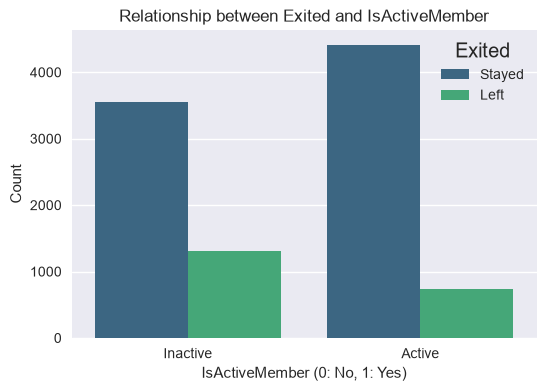

In [58]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='IsActiveMember', hue='Exited', palette='viridis')
plt.title('Relationship between Exited and IsActiveMember')
plt.xlabel('IsActiveMember (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Inactive', 'Active'])
plt.legend(title='Exited', labels=['Stayed', 'Left'])
plt.show()

In [59]:
contingency_table = pd.crosstab(df['IsActiveMember'], df['Exited'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f'Chi-Square Statistic: {chi2:.3f}, p-value: {p_value:.3f}')

Chi-Square Statistic: 243.695, p-value: 0.000


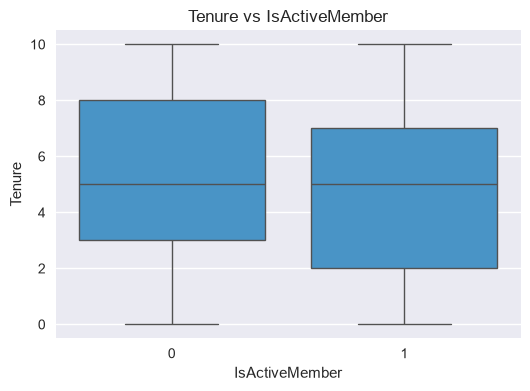

In [60]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='IsActiveMember', y='Tenure')
plt.title('Tenure vs IsActiveMember')
plt.xlabel('IsActiveMember')
plt.ylabel('Tenure')
plt.show()

In [61]:
active_0 = df[df['IsActiveMember'] == 0]['Tenure']
active_1 = df[df['IsActiveMember'] == 1]['Tenure']
stat, p_value = mannwhitneyu(active_0, active_1)
print(f'Mann-Whitney U Statistic: {stat:.3f}, p-value: {p_value:.3f}')

Mann-Whitney U Statistic: 12900304.500, p-value: 0.004


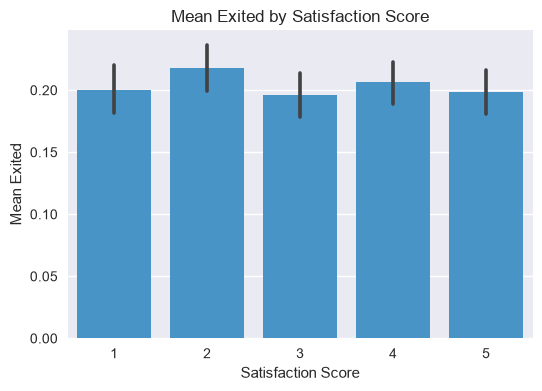

In [62]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Satisfaction Score', y='Exited', estimator='mean')
plt.title('Mean Exited by Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Mean Exited')
plt.show()


In [63]:
contingency_table = pd.crosstab(df['Satisfaction Score'], df['Exited'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f'Chi-Square Statistic: {chi2:.3f}, p-value: {p_value:.3f}')

Chi-Square Statistic: 3.803, p-value: 0.433


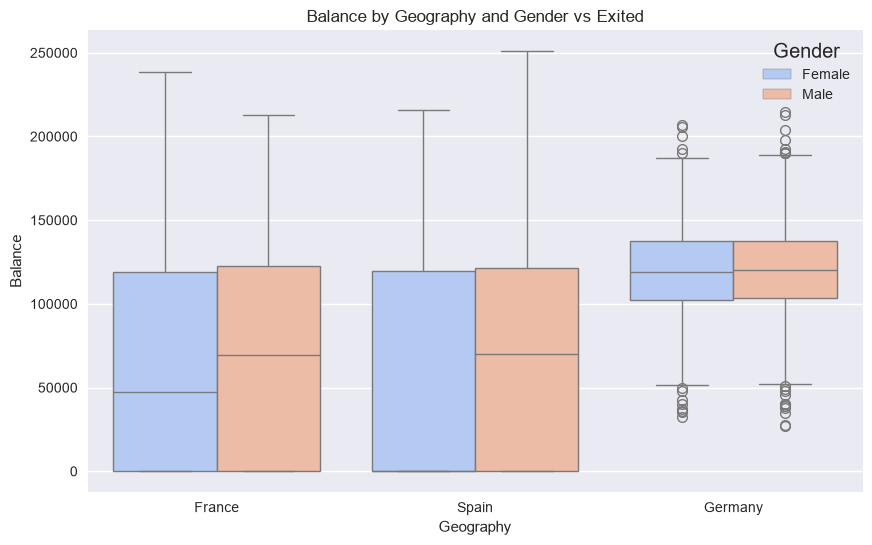

In [64]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Geography', y='Balance', hue='Gender', palette='coolwarm')
plt.title('Balance by Geography and Gender vs Exited')
plt.show()

In [65]:
contingency_table = pd.crosstab(index=[df['Geography'], df['Gender']], columns=df['Exited'])
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f'Chi-Square Statistic: {chi2:.3f}, p-value: {p_value:.3f}')

Chi-Square Statistic: 406.023, p-value: 0.000


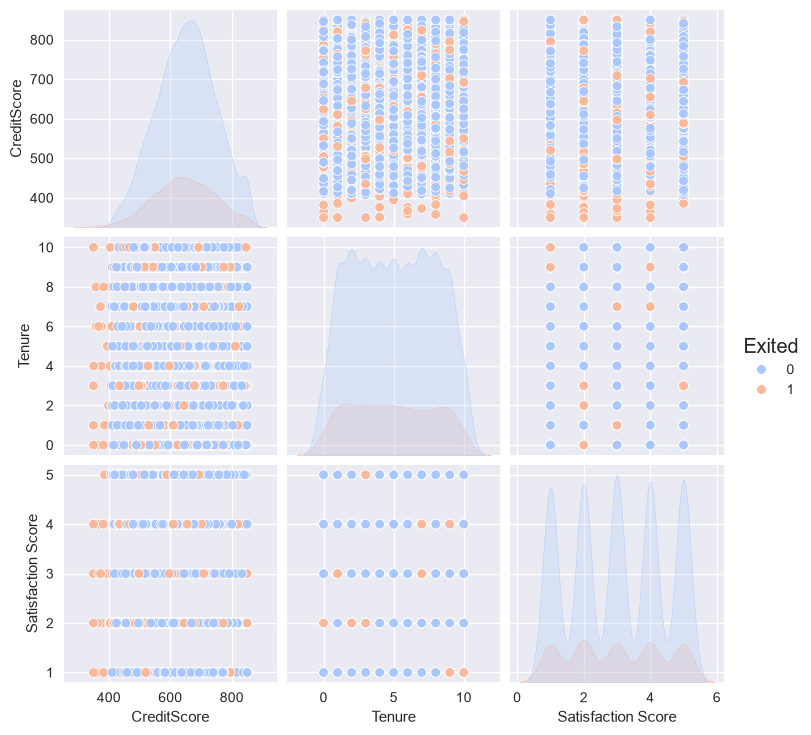

In [66]:
sns.pairplot(df[['CreditScore', 'Tenure', 'Satisfaction Score', 'Exited']],
             hue='Exited', palette='coolwarm')
plt.show()